# Topic Modelling and Theme Discovery

This notebook explores the review corpus with unsupervised methods in order to identify recurring themes.

The workflow is structured as follows:
1. Data preparation and topic-oriented text cleaning
2. Baseline and improved LDA topic modelling
3. Embedding-based clustering with Word2Vec and KMeans
4. Final comparison of the two topic-discovery approaches

## Data Preparation and topic-oriented text cleaning 

### Imports

In [1]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ----- ---------------------------------- 3.4/24.4 MB 17.1 MB/s eta 0:00:02
   ------------ --------------------------- 7.3/24.4 MB 17.5 MB/s eta 0:00:01
   ------------------ --------------------- 11.0/24.4 MB 17.9 MB/s eta 0:00:01
   ------------------------ --------------- 14.7/24.4 MB 17.7 MB/s eta 0:00:01
   ----------------------------- ---------- 18.1/24.4 MB 17.3 MB/s eta 0:00:01
   ---------------------------------- ----- 21.2/24.4 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 16.9 M

In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec, CoherenceModel
from gensim.corpora import Dictionary

from tqdm import tqdm
tqdm.pandas()

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)


### Loading the review corpus

The notebook keeps the two cleaned text fields used later for:
- bag-of-words topic modelling
- embedding-based clustering

After removing empty rows, the corpus contains **2,998 reviews**, which provides a sufficiently large basis for unsupervised theme discovery.

In [3]:
df = pd.read_csv('dataset_cleaned.csv')
df_topic = df[['avis_en_tfidf_lda', 'avis_en_embeddings']].copy()
df_topic['avis_en_tfidf_lda'] = df_topic['avis_en_tfidf_lda'].fillna('').astype(str)
df_topic['avis_en_embeddings'] = df_topic['avis_en_embeddings'].fillna('').astype(str)

df_topic = df_topic[
    (df_topic['avis_en_tfidf_lda'].str.strip() != '')
    & (df_topic['avis_en_embeddings'].str.strip() != '')
].reset_index(drop=True)

print(df_topic.shape)
df_topic.head()

(2998, 2)


,avis_en_tfidf_lda,avis_en_embeddings
0,best prices solutions listening speed recommen...,best insurance prices solutions listening spee...
1,generally satisfied problem internal site impo...,"I am generally satisfied, except that you have..."
2,affordable price options available box connect...,very affordable price several options are avai...
3,satisfied quick response thank cheapest market...,"I am satisfied with the service, a very quick ..."
4,years disappointed mutual longer mutual search...,customer for more than years very disappointed...


### Topic-oriented cleaning strategy

A stronger cleaning pipeline is applied to improve topic interpretability. In addition to standard normalization, the notebook removes generic review words such as `service`, `company`, `customer`, `price`, and `recommend`.

The objective is to reduce very frequent but weakly informative words so that the models focus more clearly on concrete themes such as claims, contracts, vehicles, payments, or advisors.

In [4]:
BASE_STOPWORDS = set(ENGLISH_STOP_WORDS)

CUSTOM_STOPWORDS = {
    'the', 'and', 'for', 'that', 'this', 'with', 'from', 'have', 'has', 'had', 'was', 'were', 'are',
    'will', 'would', 'can', 'could', 'very', 'much', 'more', 'less', 'also', 'still', 'yet', 'one',
    'two', 'get', 'got', 'made', 'make', 'go', 'goes', 'went', 'come', 'came', 'back', 'really',
    'im', 'ive', 'youre', 'theyre', 'didnt', 'doesnt', 'cant', 'wont', 'dont', 'isnt', 'wasnt',
    'service', 'services', 'company', 'insurance', 'insurer', 'customer', 'customers', 'client',
    'clients', 'opinion', 'opinions', 'regards', 'thank', 'thanks', 'best', 'good', 'great',
    'bad', 'new', 'old', 'years', 'year', 'months', 'month', 'days', 'day', 'time', 'times',
    'price', 'prices', 'satisfied', 'recommend', 'contact', 'telephone', 'online', 'site'
}

STOPWORDS = BASE_STOPWORDS | CUSTOM_STOPWORDS

CONTRACTIONS = {
    "can't": 'cannot',
    "won't": 'will not',
    "n't": ' not',
    "'re": ' are',
    "'ve": ' have',
    "'ll": ' will',
    "'d": ' would',
    "'m": ' am',
    "'s": ''
}

### Normalizing and cleaning the review text

This step prepares the review text for theme extraction.

Two functions are applied:

- `normalize_text()` standardizes the text format
- `clean_for_topics()` removes weakly informative tokens

The objective is to reduce noise and keep clearer words for topic modelling and clustering. To do this, several transformations are applied:

- lowercase conversion
- removal of URLs, digits, punctuation, and extra spaces
- expansion of common contractions
- removal of short tokens and stopwords
- removal of tokens with very low semantic value

In [5]:
def normalize_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_for_topics(text: str, min_len: int = 3) -> str:
    text = normalize_text(text)
    tokens = []
    for token in text.split():
        if len(token) < min_len:
            continue
        if token in STOPWORDS:
            continue
        if token.isdigit():
            continue
        if len(set(token)) == 1:
            continue
        tokens.append(token)
    return ' '.join(tokens)

df_topic['raw_lda_text'] = df_topic['avis_en_tfidf_lda'].map(normalize_text)
df_topic['raw_emb_text'] = df_topic['avis_en_embeddings'].map(normalize_text)
df_topic['clean_lda_text'] = df_topic['avis_en_tfidf_lda'].map(clean_for_topics)
df_topic['clean_emb_text'] = df_topic['avis_en_embeddings'].map(clean_for_topics)

df_topic = df_topic[
    (df_topic['clean_lda_text'].str.strip() != '')
    & (df_topic['clean_emb_text'].str.strip() != '')
].reset_index(drop=True)

print(df_topic.shape)
df_topic[['avis_en_tfidf_lda', 'clean_lda_text']].head(10)


(2996, 6)


,avis_en_tfidf_lda,clean_lda_text
0,best prices solutions listening speed recommen...,solutions listening speed attractive quality s...
1,generally satisfied problem internal site impo...,generally problem internal impossible declare ...
2,affordable price options available box connect...,affordable options available box connected car...
3,satisfied quick response thank cheapest market...,quick response cheapest market
4,years disappointed mutual longer mutual search...,disappointed mutual longer mutual search immed...
5,forced sale telephone claiming events loved on...,forced sale claiming events loved ones knowing...
6,new satisfied price opinions new hope goes thank,hope
7,contacted telephone sell puppy selling pretty ...,contacted sell puppy selling pretty details su...
8,join negative reviews regret having star reimb...,join negative reviews regret having star reimb...
9,generali life assets poor bad payer ask advanc...,generali life assets poor payer ask advance ge...


### Impact of cleaning on text length

In [ ]:
raw_lengths = df_topic['raw_lda_text'].str.split().map(len)
clean_lengths = df_topic['clean_lda_text'].str.split().map(len)

stats_df = pd.DataFrame({
    'raw_tokens': raw_lengths.describe(),
    'clean_tokens': clean_lengths.describe(),
})
stats_df


,raw_tokens,clean_tokens
count,2996.000000,2996.000000
mean,25.266689,22.342123
std,25.887943,24.233576
min,1.000000,1.000000
25%,11.000000,9.000000
50%,16.000000,14.000000
75%,29.000000,27.000000
max,286.000000,275.000000


The cleaning process slightly reduces the average text length.

Mean tokens: from 25.27 to 22.34
Median tokens: from 16 to 14

This confirms that the pipeline removes non-informative words without heavily altering the structure of the reviews.

The distribution remains similar: minimum and maximum values are stable and variability is preserved

This indicates that the cleaning step reduces noise while keeping the overall information content intact.

## LDA Topic Modelling

### Baseline LDA on minimally cleaned text

This first model is trained on lightly normalized text.

The objective is to observe how topics look without strong cleaning, and to establish a reference point for comparison.

In [10]:
def print_topics(model, vectorizer, n_top_words=10, title='Topics'):
    feature_names = vectorizer.get_feature_names_out()
    print(title)
    print('-' * len(title))
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_top_words:][::-1]
        words = [feature_names[i] for i in top_idx]
        print(f'Topic {topic_idx}: ' + ', '.join(words))

raw_vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.95)
X_raw = raw_vectorizer.fit_transform(df_topic['raw_lda_text'])
raw_lda = LatentDirichletAllocation(n_components=8, random_state=42, learning_method='batch')
raw_lda.fit(X_raw)

print_topics(raw_lda, raw_vectorizer, title='Baseline LDA topics')


Baseline LDA topics
-------------------
Topic 0: mutual, years, water, damage, bad, reimbursements, reimbursed, cancel, avoid, following
Topic 1: years, car, year, not, insured, expensive, price, it, direct, increase
Topic 2: life, does, response, sent, months, contact, letter, impossible, following, pay
Topic 3: not, months, time, it, do, month, am, documents, sent, pay
Topic 4: satisfied, price, prices, good, recommend, thank, simple, fast, quick, telephone
Topic 5: life, afer, redemption, years, money, savings, bank, payment, account, request
Topic 6: vehicle, axa, years, accident, insured, home, contracts, car, following, despite
Topic 7: expert, years, macif, year, damage, disaster, euros, month, house, following


The baseline topics are difficult to interpret clearly.

Many generic and frequent words still dominate the topics, such as “years”, “months” or “time”, which reduces their meaning. Several topics also mix different concepts, making it hard to identify a clear theme.

For instance, some topics combine pricing, insurance status and general vocabulary, while others mix life events, communication and claims. In some cases, the topic is mostly driven by time-related words rather than a meaningful subject.

A few weak signals can still be observed, such as pricing perception, claims and reimbursements, or insurance products. However, these themes are not clearly separated and remain noisy.

Overall, the topics lack coherence and interpretability. This shows that minimal preprocessing is not sufficient and that stronger cleaning is needed to extract clearer themes.

### Searching for the optimal number of topics

Several topic counts are tested and compared using the c_v coherence score.

The objective is to identify the number of topics that produces the most interpretable and consistent themes.

In [11]:
tokenized_texts = [text.split() for text in df_topic['clean_lda_text']]
dictionary = Dictionary(tokenized_texts)
corpus_gensim = [dictionary.doc2bow(text) for text in tokenized_texts]

def get_topic_words(model, vectorizer, topn=10):
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic in model.components_:
        top_idx = topic.argsort()[-topn:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def compute_lda_coherence(n_topics, texts):
    vectorizer = CountVectorizer(
        max_features=6000,
        min_df=8,
        max_df=0.40,
        ngram_range=(1, 2)
    )
    X = vectorizer.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        doc_topic_prior=0.3,
        topic_word_prior=0.2
    )
    lda.fit(X)
    topics = get_topic_words(lda, vectorizer, topn=10)
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v',
        processes=1
    )
    return lda, vectorizer, topics, coherence_model.get_coherence()

search_results = []
for n_topics in range(5, 11):
    _, _, _, coherence = compute_lda_coherence(n_topics, df_topic['clean_lda_text'])
    search_results.append({'n_topics': n_topics, 'coherence': coherence})

search_df = pd.DataFrame(search_results).sort_values('coherence', ascending=False)
search_df


,n_topics,coherence
0,5,0.554120
3,8,0.542492
2,7,0.523620
1,6,0.519211
5,10,0.513759
4,9,0.473095


The coherence scores show that the best configuration is obtained with 5 topics, reaching a score of 0.5541.

Other configurations such as 8 or 7 topics also provide relatively good results, but remain slightly below. As the number of topics increases, the coherence tends to decrease, which suggests that the model starts to split meaningful themes into smaller and less stable groups.

Choosing 5 topics therefore provides the best balance between interpretability and model quality. It allows the model to capture the main themes of the corpus without introducing unnecessary fragmentation.

### Final LDA model and topic quality

In [12]:
best_n_topics = int(search_df.iloc[0]['n_topics'])
lda_model, count_vectorizer, lda_topics_words, lda_coherence = compute_lda_coherence(
    best_n_topics,
    df_topic['clean_lda_text']
)
X_bow = count_vectorizer.transform(df_topic['clean_lda_text'])
lda_topic_distrib = lda_model.transform(X_bow)
df_topic['lda_topic'] = np.argmax(lda_topic_distrib, axis=1)
df_topic['lda_confidence'] = lda_topic_distrib.max(axis=1)

print(f'Best number of topics: {best_n_topics}')
print(f'LDA coherence score: {lda_coherence:.4f}')
print_topics(lda_model, count_vectorizer, title='Improved LDA topics (texte nettoye)')


Best number of topics: 5
LDA coherence score: 0.5541
Improved LDA topics (texte nettoye)
-----------------------------------
Topic 0: sent, documents, letter, pay, does, received, life, payment, cardif, did
Topic 1: vehicle, car, accident, insured, expensive, problem, home, insure, responsible, change
Topic 2: simple, fast, attractive, quick, easy, clear, efficient, attentive, direct, friendly
Topic 3: account, request, afer, taken, mutual, waiting, told, care, life, response
Topic 4: damage, disaster, expert, maif, euros, water, following, water damage, insured, pay


The final model uses 5 topics and achieves a coherence score of 0.5541, confirming the previous selection.

Compared to the baseline, the topics are now significantly clearer and more structured. Each topic is centered around a consistent theme, with less noise and fewer generic terms.

Distinct themes emerge more clearly. Some topics relate to administrative processes such as documents, payments and life insurance cases, while others focus on vehicle-related issues, including accidents and insurance coverage. Service experience also appears as a separate theme, with words reflecting speed, simplicity and customer satisfaction. Another topic captures account management and response delays, and a final one focuses on damage, experts and incident handling.

The separation between topics is much stronger than in the baseline model, with limited overlap in vocabulary. This is confirmed by a high topic diversity score of 0.94, indicating that each topic relies on a distinct set of words.

Overall, the improved LDA model provides a more interpretable and reliable representation of the main themes in the corpus.

### Representative Failure Cases for LDA
Representative documents are not only useful for interpretation; they also reveal weak topics. If the examples look semantically mixed or overly generic, that is evidence that the topic configuration still has limitations.


In [13]:
def topic_diversity(topics, topk=10):
    unique_words = set(word for topic in topics for word in topic[:topk])
    return len(unique_words) / (len(topics) * topk)

lda_diversity = topic_diversity(lda_topics_words, topk=10)
print(f'LDA topic diversity: {lda_diversity:.4f}')


LDA topic diversity: 0.9400


This step measures how distinct the topics are in terms of vocabulary.

A diversity score of 0.94 indicates that most words are not shared across topics. This means that each topic relies on a specific set of terms, with very limited overlap.

This confirms that the model produces well-separated and non-redundant topics, which is a strong indicator of good topic quality.

## Reading representative LDA examples

This step displays the most representative reviews for each topic.
The goal is to validate the topics using real text, not only keywords.

In [14]:
def show_representative_examples(df, topic_col, text_col, score_col, n_examples=3):
    for topic_id in sorted(df[topic_col].unique()):
        print('=' * 100)
        print(f'TOPIC {topic_id}')
        print('Top words:', ', '.join(lda_topics_words[topic_id]))
        subset = df[df[topic_col] == topic_id].sort_values(score_col, ascending=False).head(n_examples)
        for i, text in enumerate(subset[text_col], 1):
            print(f'Example {i}: {text}')
        print()

show_representative_examples(df_topic, 'lda_topic', 'avis_en_embeddings', 'lda_confidence', n_examples=3)


TOPIC 0
Top words: sent, documents, letter, pay, does, received, life, payment, cardif, did
Example 1: following your decision on my file I am not in agreement with you in fact you tell me that I did not declare my treatment for my tension when I put together my loan file with the salesman he said that for this it was not necessary and that at the signature no one from domifinance or from you even cardif sent us a letter in this direction how do you want me to know but my request does not in any way concern a problem with my tension but a problem with pain with my left hip I am holyly obliged to walk with canes so I think that there is no point in paying insurance if that does not take into account when you had a health problem and if I die my wife would have to continue paying the loan because we have not started my treatment for my blood pressure! and if I have my hip problem I become disabled should I continue to pay? with this small disability pension. I think I'm going to go see t

Reading representative examples confirms that the topics are globally coherent.

The texts associated with each topic match the extracted keywords and reveal clear underlying themes. Administrative issues, vehicle-related situations, service experience, account management and damage cases are all reflected in real user reviews.

Some topics are particularly well defined, especially those related to service quality and vehicle incidents, where the examples are very consistent with the top words.

A few limitations still appear. Certain examples remain slightly noisy or contain multiple signals, especially in topics related to administrative processes. This reflects the natural complexity of user reviews, which often combine several issues in a single text.

Overall, this qualitative validation confirms that the model captures meaningful and interpretable themes, while highlighting a small level of residual noise.

## Embeddings + Clustering

### Word2Vec document embeddings

This step builds a semantic representation of the reviews using Word2Vec. Each word is mapped to a vector, and document vectors are obtained by averaging the vectors of their words.

In [15]:
texts_emb = df_topic['clean_emb_text'].tolist()
tokenized_emb = [text.split() for text in texts_emb]

w2v_model = Word2Vec(
    sentences=tokenized_emb,
    vector_size=100,
    window=5,
    min_count=3,
    workers=1,
    sg=1,
    epochs=30,
    seed=42
)

def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_emb = np.vstack([document_vector(tokens, w2v_model) for tokens in tokenized_emb])
X_emb.shape


(2996, 100)

The embedding matrix has a shape of (2996, 100), meaning that each review is represented by a 100-dimensional vector.

### Searching for the best number of clusters

KMeans is tested with **5 to 10 clusters** and evaluated with the silhouette score.


In [16]:
cluster_search = []
for n_clusters in range(5, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_emb)
    sil = silhouette_score(X_emb, labels)
    cluster_search.append({'n_clusters': n_clusters, 'silhouette': sil})

cluster_search_df = pd.DataFrame(cluster_search).sort_values('silhouette', ascending=False)
cluster_search_df


,n_clusters,silhouette
0,5,0.043437
1,6,0.043192
2,7,0.037361
3,8,0.036732
4,9,0.035557
5,10,0.034121


The best result is obtained with **5 clusters**, with a silhouette score of **0.0434**. The score for **6 clusters** is very close at **0.0432**, while all larger values perform worse. Although **5 clusters** is the best option in this search, the absolute silhouette score remains low.

This means that the clusters exist, but they are only weakly separated in the embedding space. In practice, clustering still provides interpretable groups, but the geometric separation is not strong.

In [17]:
best_n_clusters = int(cluster_search_df.iloc[0]['n_clusters'])
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42, n_init=20)
df_topic['cluster_kmeans'] = kmeans.fit_predict(X_emb)
sil_score = silhouette_score(X_emb, df_topic['cluster_kmeans'])

print(f'Best number of clusters: {best_n_clusters}')
print(f'Silhouette score (KMeans): {sil_score:.4f}')

Best number of clusters: 5
Silhouette score (KMeans): 0.0434


The final KMeans model keeps **5 clusters**. Cluster keywords show themes that are easy to interpret, such as:
- advisors, phone support, and responsiveness
- simple, fast, and practical subscription journeys
- experts, damage, and disaster handling
- contracts, files, letters, and payments
- price increases, guarantees, and car contracts

The clustering approach reaches a coherence of **0.5744**, which is slightly higher than LDA (**0.5541**). Its topic diversity is **0.90**, a bit lower than LDA (**0.94**) but still high enough to indicate that the clusters remain distinct.

This suggests that the embedding-based pipeline produces slightly more semantically coherent groups, even if vocabulary overlap is a little higher.

### Extracting cluster keywords

This step assigns interpretable keywords to each cluster.
Texts are grouped by cluster, then a TF-IDF representation is used to identify the most important terms within each group.

In [18]:
def extract_cluster_keywords_ctfidf(df, cluster_col, text_col, top_n=10):
    cluster_docs = (
        df.groupby(cluster_col)[text_col]
        .apply(lambda texts: ' '.join(texts))
        .sort_index()
    )
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    X = vectorizer.fit_transform(cluster_docs)
    feature_names = vectorizer.get_feature_names_out()
    keywords = {}
    for row_idx, cluster_id in enumerate(cluster_docs.index):
        row = X[row_idx].toarray().ravel()
        top_idx = row.argsort()[-top_n:][::-1]
        keywords[int(cluster_id)] = [feature_names[i] for i in top_idx if row[i] > 0]
    return keywords

cluster_keywords = extract_cluster_keywords_ctfidf(
    df_topic,
    cluster_col='cluster_kmeans',
    text_col='clean_emb_text',
    top_n=10
)

for cluster_id, words in cluster_keywords.items():
    print(f'Cluster {cluster_id}: ' + ', '.join(words))


Cluster 0: advisor, contract, attentive, friendly, advice, advisors, information, quickly, phone, pleasant
Cluster 1: fast, simple, quick, easy, practical, efficient, attractive, clear, simple practical, competitive
Cluster 2: expert, damage, disaster, maif, water, insured, following, file, macif, car
Cluster 3: contract, file, letter, mutual, afer, sent, documents, does, pay, life
Cluster 4: contract, increase, car, expensive, euros, insured, direct, guarantees, vehicle, bonus


The extracted keywords provide a clear interpretation of each cluster.

Unlike LDA, where topics are directly produced by the model, clustering requires this additional step to understand the content of each group.

The clusters reveal distinct themes. Some are centered on customer interaction and advice, others on service quality and efficiency, while additional groups capture claims, administrative processes, or pricing issues.

The keywords are generally coherent and align well with meaningful business topics. This confirms that the embedding-based clustering is able to group similar reviews effectively, even when different vocabulary is used.

### Scoring the clusters with coherence and diversity

You evaluate the cluster keyword sets with coherence and diversity so they can be compared more fairly with the LDA topics. That keeps the final comparison from being purely visual or anecdotal.

In [19]:
cluster_topics_words = [words for _, words in sorted(cluster_keywords.items())]
coherence_model_cluster = CoherenceModel(
    topics=cluster_topics_words,
    texts=tokenized_emb,
    dictionary=Dictionary(tokenized_emb),
    coherence='c_v',
    processes=1
)
cluster_coherence = coherence_model_cluster.get_coherence()
cluster_diversity = topic_diversity(cluster_topics_words, topk=10)

print(f'Embedding + KMeans coherence: {cluster_coherence:.4f}')
print(f'Embedding + KMeans diversity: {cluster_diversity:.4f}')


Embedding + KMeans coherence: 0.5744
Embedding + KMeans diversity: 0.9000


The clustering approach achieves a coherence score of 0.5744 and a diversity score of 0.90.

The coherence is slightly higher than the LDA model, which suggests that the clusters are semantically consistent and group related terms effectively. This confirms that the embedding-based approach captures meaningful relationships between words and documents.

The diversity remains high, although slightly below LDA. This indicates that most clusters rely on distinct vocabularies, with limited overlap between themes.

Overall, the results show that clustering with embeddings produces well-structured and coherent groups, with a strong semantic consistency and a level of diversity comparable to LDA.

### Reading representative clustering examples
This step displays the most representative reviews for each cluster based on their proximity to the cluster centers.
The objective is to validate whether clusters correspond to clear themes or simply group similar tones.


In [20]:
def show_cluster_examples(df, cluster_col, text_col, embeddings, centers, n_examples=3):
    similarities = cosine_similarity(embeddings, centers)
    for cluster_id in sorted(df[cluster_col].unique()):
        print('=' * 100)
        print(f'CLUSTER {cluster_id}')
        print('Top words:', ', '.join(cluster_keywords[cluster_id]))
        cluster_indices = np.where(df[cluster_col].to_numpy() == cluster_id)[0]
        scores = similarities[cluster_indices, cluster_id]
        best_local = cluster_indices[np.argsort(scores)[::-1][:n_examples]]
        for rank, idx in enumerate(best_local, 1):
            print(f'Example {rank}: {df.iloc[idx][text_col]}')
        print()

show_cluster_examples(
    df_topic,
    cluster_col='cluster_kmeans',
    text_col='avis_en_embeddings',
    embeddings=X_emb,
    centers=kmeans.cluster_centers_,
    n_examples=3
)


CLUSTER 0
Top words: advisor, contract, attentive, friendly, advice, advisors, information, quickly, phone, pleasant
Example 1: attractive value for money, responsive and attentive advisors; is my first subscription to car insurance and I was delighted with the step-by-step support from the tele-advisors who explained the various terms of this contract to me and answered all my questions
Example 2: we always criticize when things are not going well but for once I am so satisfied that I cannot let criticize an insurance company whose advice saved my day. Already when signing my contract I was extremely well advised but I didn't know it yet, I noticed it when my vehicle was stolen. traumatized by this theft, I contacted the GMF and its services in Besançon several times. I had several contacts who were all very pleasant and very understandable after all the obligatory steps and procedures. The GMF reimbursed me in full without any problem within a very reasonable time frame. As a result,

Reading the representative examples shows that the clusters are generally coherent and reflect meaningful themes.

Some clusters are clearly defined, such as service quality or damage and claims. However, others mix several situations, especially when reviews combine multiple issues.

There is also a tendency to group reviews with a similar tone, even when the underlying topics differ.

Overall, clustering captures semantic similarity well, but remains less precise than LDA for separating distinct themes.

### Visualizing clusters with t-SNE

This step projects the document embeddings into two dimensions using t-SNE. The goal is to visually assess how well the clusters are separated.

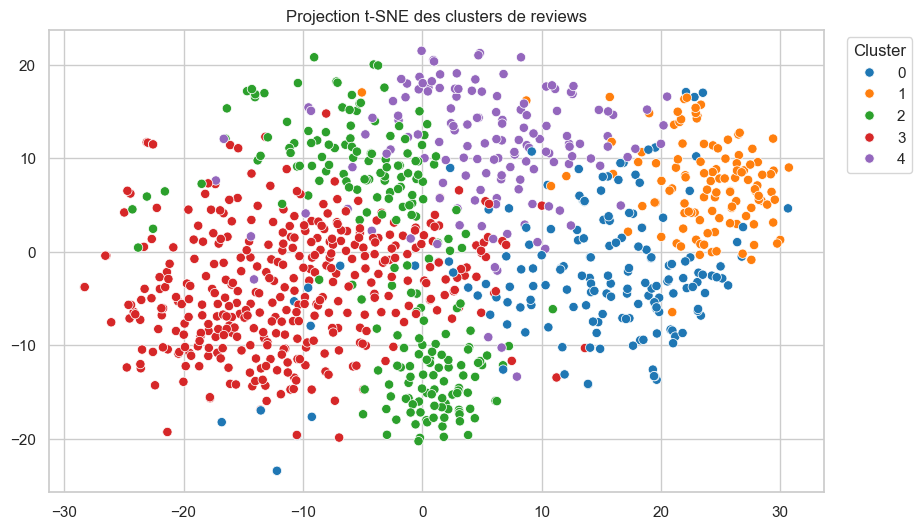

In [21]:
sample_size = min(1000, len(df_topic))
sample_idx = np.random.RandomState(42).choice(len(df_topic), size=sample_size, replace=False)

X_sample = X_emb[sample_idx]
labels_sample = df_topic.iloc[sample_idx]['cluster_kmeans'].to_numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_sample, palette='tab10', s=45)
plt.title('Projection t-SNE des clusters de reviews')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


The visualization shows that some clusters are well separated, while others partially overlap.

Certain groups form compact and distinct regions, which indicates strong semantic similarity within those clusters. However, overlaps between clusters suggest that some themes are close or not clearly distinguishable.

This confirms that clustering captures global structure, but does not always produce sharply separated groups.

## Final comparison

### Preparing topic summaries for an LLM

This step creates a structured summary for each cluster using keywords and representative examples.

In [22]:
def build_topic_summary_for_llm(topic_words_dict, df, topic_col, text_col, n_examples=3):
    summaries = []
    for topic_id, words in topic_words_dict.items():
        examples = df[df[topic_col] == topic_id][text_col].head(n_examples).tolist()
        summaries.append({
            'topic_id': topic_id,
            'top_words': words,
            'examples': examples
        })
    return summaries

kmeans_llm_input = build_topic_summary_for_llm(
    topic_words_dict=cluster_keywords,
    df=df_topic,
    topic_col='cluster_kmeans',
    text_col='avis_en_embeddings',
    n_examples=3
)


### Generating a naming prompt for one topic

You turn the cluster summary into a prompt that asks for a short label, a one-sentence explanation, and a coherence judgment. This is a neat bridge between unsupervised modeling and manual topic interpretation.

In [23]:
def make_llm_prompt(topic_info):
    prompt = f'''
You are analyzing customer review topics.

Topic ID: {topic_info['topic_id']}
Top words: {', '.join(topic_info['top_words'])}

Examples:
'''
    for i, ex in enumerate(topic_info['examples'], 1):
        prompt += f'\nExample {i}: {ex}\n'
    prompt += '''

Task:
1. Give a short topic label.
2. Explain the main theme in one sentence.
3. Say whether the topic seems coherent or mixed.
'''
    return prompt

print(make_llm_prompt(kmeans_llm_input[0]))



You are analyzing customer review topics.

Topic ID: 0
Top words: advisor, contract, attentive, friendly, advice, advisors, information, quickly, phone, pleasant

Examples:

Example 1: I am generally satisfied, except that you have a problem with your internal site, it is impossible to declare a claim online after several attempts, declaration made by telephone or everything went very well, competent and very pleasant interlocutor

Example 2: totally satisfied with the quality of telephone support, always well understood and with oral information followed by real effects

Example 3: the customer service telephone interface is quite intuitive, my interlocutor (rira) was very understanding and was able to explain to me the steps to follow clearly, I thank her for that


Task:
1. Give a short topic label.
2. Explain the main theme in one sentence.
3. Say whether the topic seems coherent or mixed.



The generated prompt combines keywords and representative examples to provide enough context for interpretation.

It guides the language model to produce a short label, a concise explanation, and a judgment on topic coherence.

This step transforms raw clustering outputs into structured, interpretable insights.

### Comparing the two topic-discovery approaches

This step compares LDA and embedding-based clustering using coherence and diversity scores.

In [ ]:
results_topics = pd.DataFrame({
    'Method': ['LDA improved', 'Embeddings + KMeans improved'],
    'Coherence': [lda_coherence, cluster_coherence],
    'Topic_Diversity': [lda_diversity, cluster_diversity]
})

results_topics


,Method,Coherence,Topic_Diversity
0,LDA improved,0.554120,0.94
1,Embeddings + KMeans improved,0.574436,0.90


Both approaches show strong performance, but with different strengths.

The embedding-based method achieves a slightly higher coherence score, indicating better semantic consistency within clusters. In contrast, LDA shows a higher topic diversity, suggesting a clearer separation between themes.

This highlights a trade-off between the two methods. Clustering captures semantic similarity more effectively, while LDA produces more distinct and interpretable topics.

Overall, LDA remains more structured for topic extraction, whereas embeddings provide a more flexible and semantically rich grouping of reviews.

### Visualizing the final topic-model comparison

This step visualizes coherence and diversity scores for both approaches.

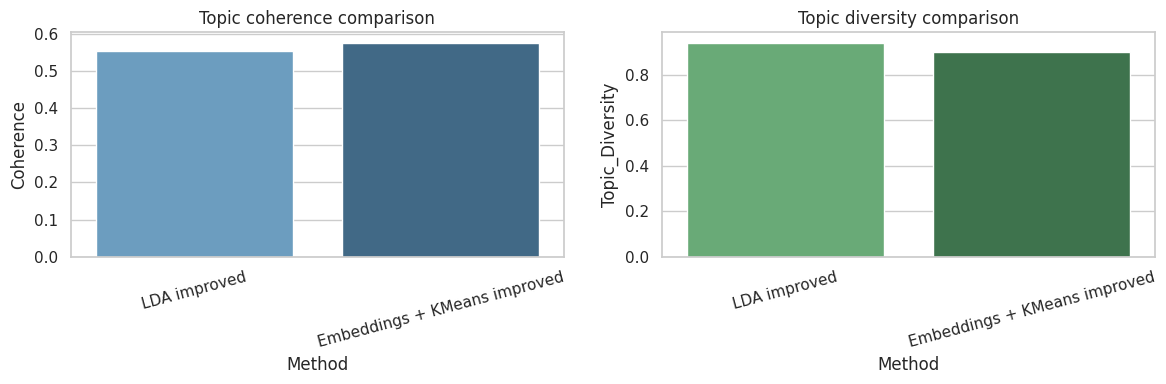

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results_topics, x='Method', y='Coherence', ax=axes[0], palette='Blues_d')
axes[0].set_title('Topic coherence comparison')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=results_topics, x='Method', y='Topic_Diversity', ax=axes[1], palette='Greens_d')
axes[1].set_title('Topic diversity comparison')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


The visualization confirms the trade-off between the two methods.

Clustering achieves higher coherence, while LDA shows higher topic diversity. This reflects the difference between semantic grouping and clearer topic separation.

Overall, both approaches perform well, but serve slightly different objectives in topic discovery.

## Global conclusion

The improved preprocessing makes a real difference here: the notebook no longer relies only on raw high-frequency words, and both topic-discovery pipelines become more interpretable. For LDA, the coherence search points to **5 topics** as the best setting, with a coherence score of `0.554`. The topic diversity is also very strong (`0.94`), which means the model avoids repeating the same vocabulary too heavily across topics. That is a good sign for interpretability.

The embedding-based pipeline performs slightly better on coherence: **`Embeddings + KMeans improved`** reaches `0.574` coherence, compared with `0.554` for LDA. Its diversity is a bit lower (`0.90` versus `0.94`), but still high enough to suggest that the clusters are not collapsing into the same keyword lists. Taken together, that means the embedding-plus-clustering approach produces the best balance in this notebook if your main criterion is semantic coherence, while LDA remains a very solid alternative if you value a bit more lexical separation between topics.

If you need to choose one final topic model from these results, the best option is **`Embeddings + KMeans improved`** because it delivers the highest coherence while keeping diversity at a good level. It looks like the strongest overall method in the current comparison. LDA is still valuable, though, especially if you want a more classical and often easier-to-explain topic model for presentation.